---
# 🔵 GAN Type 1 — Vanilla GAN (MLP-based)
Standard GAN using fully connected layers only. No class conditioning — purely unsupervised generation.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
latent_dim = 100
batch_size = 128        # larger batch → better GPU utilisation on T4
lr = 0.0002
epochs = 300
checkpoint_dir = "/content/checkpoints/vanilla_gan"
image_dir      = "/content/images/vanilla_gan"
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(image_dir, exist_ok=True)

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,      # T4 Colab has 2 CPU cores available
    pin_memory=True     # faster CPU→GPU transfers
)

100%|██████████| 26.4M/26.4M [00:03<00:00, 8.80MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 140kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.55MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.7MB/s]


In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
G = Generator().to(device)
D = Discriminator().to(device)

In [ ]:
criterion = nn.BCELoss()

optimizer_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

In [ ]:
for epoch in range(1, epochs + 1):
    G.train()
    D.train()
    for i, (real_imgs, _) in enumerate(dataloader):

        real_imgs = real_imgs.view(-1, 784).to(device, non_blocking=True)
        batch_size_curr = real_imgs.size(0)

        real_labels = torch.ones(batch_size_curr, 1, device=device)
        fake_labels = torch.zeros(batch_size_curr, 1, device=device)

        # =======================
        # Train Discriminator
        # =======================
        outputs = D(real_imgs)
        loss_real = criterion(outputs, real_labels)

        z = torch.randn(batch_size_curr, latent_dim, device=device)
        fake_imgs = G(z)
        outputs = D(fake_imgs.detach())
        loss_fake = criterion(outputs, fake_labels)

        loss_D = loss_real + loss_fake

        optimizer_D.zero_grad()
        loss_D.backward()
        optimizer_D.step()

        # =======================
        # Train Generator
        # =======================
        z = torch.randn(batch_size_curr, latent_dim, device=device)
        fake_imgs = G(z)
        outputs = D(fake_imgs)

        loss_G = criterion(outputs, real_labels)

        optimizer_G.zero_grad()
        loss_G.backward()
        optimizer_G.step()

    print(f"Epoch [{epoch}/{epochs}]  Loss D: {loss_D.item():.4f},  Loss G: {loss_G.item():.4f}")

    # ── Save checkpoint + images every 10 epochs ────────────────────────
    if epoch % 20 == 0:
        # Checkpoint
        ckpt_path = os.path.join(checkpoint_dir, f"epoch_{epoch:03d}.pt")
        torch.save({
            "epoch": epoch,
            "generator_state_dict": G.state_dict(),
            "discriminator_state_dict": D.state_dict(),
            "optimizer_G_state_dict": optimizer_G.state_dict(),
            "optimizer_D_state_dict": optimizer_D.state_dict(),
            "loss_G": loss_G.item(),
            "loss_D": loss_D.item(),
        }, ckpt_path)
        print(f"  ✅ Checkpoint saved → {ckpt_path}")

        # Generated image grid
        G.eval()
        with torch.no_grad():
            z_fixed = torch.randn(16, latent_dim, device=device)
            sample_imgs = G(z_fixed).view(-1, 1, 28, 28).cpu()
        G.train()

        fig, axes = plt.subplots(4, 4, figsize=(6, 6))
        for idx, ax in enumerate(axes.flat):
            ax.imshow(sample_imgs[idx][0], cmap='gray')
            ax.axis('off')
        plt.suptitle(f"Vanilla GAN — Epoch {epoch}")
        plt.tight_layout()
        img_path = os.path.join(image_dir, f"epoch_{epoch:03d}.png")
        plt.savefig(img_path, dpi=80, bbox_inches='tight')
        plt.close()
        print(f"  🖼️  Image saved   → {img_path}")

Epoch [1/300]  Loss D: 0.6620,  Loss G: 4.1449
Epoch [2/300]  Loss D: 0.4779,  Loss G: 3.3015
Epoch [3/300]  Loss D: 0.2614,  Loss G: 3.6449
Epoch [4/300]  Loss D: 0.3777,  Loss G: 2.6399
Epoch [5/300]  Loss D: 0.6011,  Loss G: 4.2743
Epoch [6/300]  Loss D: 0.5644,  Loss G: 2.8929
Epoch [7/300]  Loss D: 0.5625,  Loss G: 2.9172
Epoch [8/300]  Loss D: 0.8795,  Loss G: 1.1815
Epoch [9/300]  Loss D: 0.9797,  Loss G: 1.4753
Epoch [10/300]  Loss D: 1.0208,  Loss G: 2.1763
Epoch [11/300]  Loss D: 0.9702,  Loss G: 1.4247
Epoch [12/300]  Loss D: 1.2002,  Loss G: 0.9201
Epoch [13/300]  Loss D: 1.1145,  Loss G: 1.1454
Epoch [14/300]  Loss D: 1.1780,  Loss G: 0.9021
Epoch [15/300]  Loss D: 1.1196,  Loss G: 1.3907
Epoch [16/300]  Loss D: 1.1258,  Loss G: 1.3253
Epoch [17/300]  Loss D: 1.2079,  Loss G: 1.0974
Epoch [18/300]  Loss D: 1.2516,  Loss G: 1.0175
Epoch [19/300]  Loss D: 1.3148,  Loss G: 0.7661
Epoch [20/300]  Loss D: 1.2299,  Loss G: 1.1618
  ✅ Checkpoint saved → /content/checkpoints/vanil

KeyboardInterrupt: 

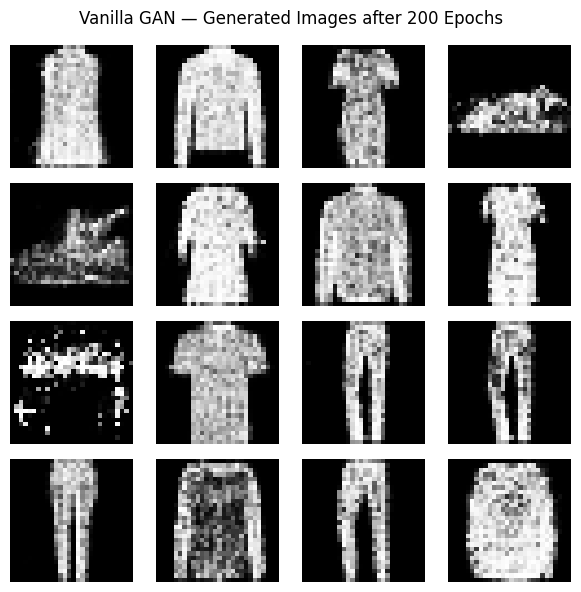

All Vanilla GAN images saved in: /content/images/vanilla_gan


In [ ]:
# ── Final visualisation ────────────────────────────────────────────────
G.eval()
with torch.no_grad():
    z = torch.randn(16, latent_dim, device=device)
    fake_images = G(z).view(-1, 1, 28, 28).cpu()

fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(fake_images[i][0], cmap='gray')
    ax.axis('off')
plt.suptitle("Vanilla GAN — Generated Images after 200 Epochs")
plt.tight_layout()
plt.savefig(os.path.join(image_dir, "final.png"), dpi=100, bbox_inches='tight')
plt.show()
print(f"All Vanilla GAN images saved in: {image_dir}")

---
# 🟡 GAN Type 2 — Conditional GAN (cGAN)
Extends the vanilla GAN with class label conditioning via embeddings, enabling controlled image generation.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

latent_dim  = 100
num_classes = 10
batch_size  = 128       # T4-friendly batch size
epochs      = 200
lr          = 0.0002
checkpoint_dir = "/content/checkpoints/cgan"
image_dir      = "/content/images/cgan"
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(image_dir, exist_ok=True)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset    = torchvision.datasets.FashionMNIST(root="./data", train=True, transform=transform, download=True)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        self.model = nn.Sequential(
            nn.Linear(latent_dim + num_classes, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Tanh()
        )

    def forward(self, z, labels):
        c = self.label_emb(labels)
        x = torch.cat([z, c], dim=1)
        return self.model(x)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        self.model = nn.Sequential(
            nn.Linear(784 + num_classes, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        c = self.label_emb(labels)
        x = torch.cat([img, c], dim=1)
        return self.model(x)


G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

In [ ]:
class_names = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal",  "Shirt",   "Sneaker",  "Bag",   "Ankle boot"]

for epoch in range(1, epochs + 1):
    G.train()
    D.train()
    for real_imgs, labels in dataloader:

        real_imgs = real_imgs.view(-1, 784).to(device, non_blocking=True)
        labels    = labels.to(device, non_blocking=True)
        b         = real_imgs.size(0)

        real = torch.ones(b, 1, device=device)
        fake = torch.zeros(b, 1, device=device)

        # Train D
        out       = D(real_imgs, labels)
        loss_real = criterion(out, real)

        z         = torch.randn(b, latent_dim, device=device)
        fake_imgs = G(z, labels)
        out       = D(fake_imgs.detach(), labels)
        loss_fake = criterion(out, fake)

        loss_D = loss_real + loss_fake
        opt_D.zero_grad(); loss_D.backward(); opt_D.step()

        # Train G
        z         = torch.randn(b, latent_dim, device=device)
        fake_imgs = G(z, labels)
        out       = D(fake_imgs, labels)
        loss_G    = criterion(out, real)

        opt_G.zero_grad(); loss_G.backward(); opt_G.step()

    print(f"Epoch {epoch}/{epochs}  LossD={loss_D.item():.4f}  LossG={loss_G.item():.4f}")

    # ── Save checkpoint + images every 10 epochs ────────────────────────
    if epoch % 20 == 0:
        # Checkpoint
        ckpt_path = os.path.join(checkpoint_dir, f"epoch_{epoch:03d}.pt")
        torch.save({
            "epoch": epoch,
            "generator_state_dict": G.state_dict(),
            "discriminator_state_dict": D.state_dict(),
            "optimizer_G_state_dict": opt_G.state_dict(),
            "optimizer_D_state_dict": opt_D.state_dict(),
            "loss_G": loss_G.item(),
            "loss_D": loss_D.item(),
        }, ckpt_path)
        print(f"  ✅ Checkpoint saved → {ckpt_path}")

        # One sample per class
        G.eval()
        with torch.no_grad():
            z_fixed  = torch.randn(10, latent_dim, device=device)
            lbl_fixed = torch.arange(10, device=device)
            sample_imgs = G(z_fixed, lbl_fixed).view(-1, 1, 28, 28).cpu()
        G.train()

        fig, axes = plt.subplots(1, 10, figsize=(15, 2))
        for idx, ax in enumerate(axes):
            ax.imshow(sample_imgs[idx][0], cmap='gray')
            ax.set_title(class_names[idx], fontsize=7)
            ax.axis('off')
        plt.suptitle(f"cGAN — Epoch {epoch}")
        plt.tight_layout()
        img_path = os.path.join(image_dir, f"epoch_{epoch:03d}.png")
        plt.savefig(img_path, dpi=80, bbox_inches='tight')
        plt.close()
        print(f"  🖼️  Image saved   → {img_path}")

Epoch 1/200  LossD=0.1247  LossG=3.7737
Epoch 2/200  LossD=0.8384  LossG=3.1108
Epoch 3/200  LossD=0.3274  LossG=3.3877
Epoch 4/200  LossD=0.4569  LossG=4.0021
Epoch 5/200  LossD=0.6711  LossG=4.0186
Epoch 6/200  LossD=0.7549  LossG=3.8662
Epoch 7/200  LossD=0.9211  LossG=2.2294
Epoch 8/200  LossD=0.8652  LossG=1.4345
Epoch 9/200  LossD=1.5114  LossG=3.9671
Epoch 10/200  LossD=0.9380  LossG=1.0461
Epoch 11/200  LossD=0.9291  LossG=1.5404
Epoch 12/200  LossD=1.0181  LossG=1.8223
Epoch 13/200  LossD=0.8850  LossG=1.2718
Epoch 14/200  LossD=1.0778  LossG=1.4499
Epoch 15/200  LossD=1.1115  LossG=1.6524
Epoch 16/200  LossD=0.9775  LossG=1.2483
Epoch 17/200  LossD=1.1166  LossG=1.2070
Epoch 18/200  LossD=1.2931  LossG=2.4508
Epoch 19/200  LossD=1.1525  LossG=1.3091
Epoch 20/200  LossD=1.2248  LossG=1.2911
  ✅ Checkpoint saved → /content/checkpoints/cgan/epoch_020.pt
  🖼️  Image saved   → /content/images/cgan/epoch_020.png
Epoch 21/200  LossD=1.3990  LossG=0.6520
Epoch 22/200  LossD=1.2481  L

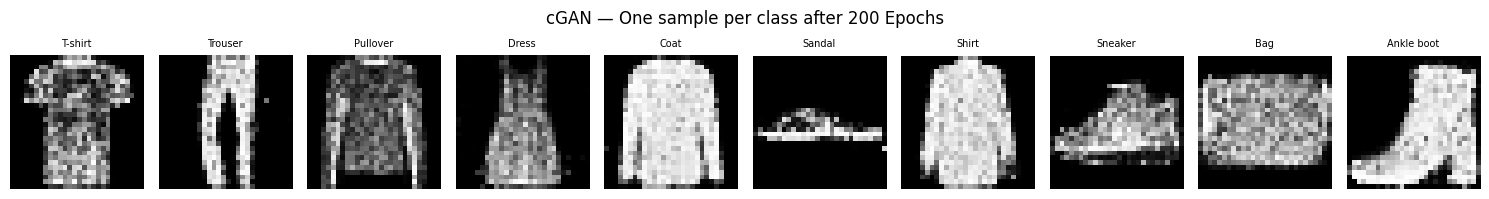

All cGAN images saved in: /content/images/cgan


In [ ]:
# ── Final visualisation ────────────────────────────────────────────────
G.eval()
with torch.no_grad():
    z      = torch.randn(10, latent_dim, device=device)
    labels = torch.arange(10, device=device)
    imgs   = G(z, labels).view(-1, 1, 28, 28).cpu()

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, ax in enumerate(axes):
    ax.imshow(imgs[i][0], cmap='gray')
    ax.set_title(class_names[i], fontsize=7)
    ax.axis('off')
plt.suptitle("cGAN — One sample per class after 200 Epochs")
plt.tight_layout()
plt.savefig(os.path.join(image_dir, "final.png"), dpi=100, bbox_inches='tight')
plt.show()
print(f"All cGAN images saved in: {image_dir}")

---
# 🟢 GAN Type 3 — DCGAN (Deep Convolutional GAN)
Uses convolutional and transposed convolutional layers. Works directly on 2D image tensors with BatchNorm for stability.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

latent_dim = 100
batch_size = 128        # T4-friendly batch size
epochs     = 200
lr         = 0.0002
checkpoint_dir = "/content/checkpoints/dcgan"
image_dir      = "/content/images/dcgan"
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(image_dir, exist_ok=True)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset    = torchvision.datasets.FashionMNIST(root="./data", train=True, transform=transform, download=True)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 256, 7, 1, 0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 1, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        z = z.unsqueeze(2).unsqueeze(3)
        return self.model(z)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1, 128, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Flatten(),
            nn.Linear(256 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.model(img)


G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

In [ ]:
for epoch in range(1, epochs + 1):
    G.train()
    D.train()
    for real_imgs, _ in dataloader:

        real_imgs = real_imgs.to(device, non_blocking=True)
        b = real_imgs.size(0)

        real = torch.ones(b, 1, device=device)
        fake = torch.zeros(b, 1, device=device)

        # Train D
        out       = D(real_imgs)
        loss_real = criterion(out, real)

        z         = torch.randn(b, latent_dim, device=device)
        fake_imgs = G(z)
        out       = D(fake_imgs.detach())
        loss_fake = criterion(out, fake)

        loss_D = loss_real + loss_fake
        opt_D.zero_grad(); loss_D.backward(); opt_D.step()

        # Train G
        z         = torch.randn(b, latent_dim, device=device)
        fake_imgs = G(z)
        out       = D(fake_imgs)
        loss_G    = criterion(out, real)

        opt_G.zero_grad(); loss_G.backward(); opt_G.step()

    print(f"Epoch {epoch}/{epochs}  LossD={loss_D.item():.4f}  LossG={loss_G.item():.4f}")

    # ── Save checkpoint + images every 10 epochs ────────────────────────
    if epoch % 20 == 0:
        # Checkpoint
        ckpt_path = os.path.join(checkpoint_dir, f"epoch_{epoch:03d}.pt")
        torch.save({
            "epoch": epoch,
            "generator_state_dict": G.state_dict(),
            "discriminator_state_dict": D.state_dict(),
            "optimizer_G_state_dict": opt_G.state_dict(),
            "optimizer_D_state_dict": opt_D.state_dict(),
            "loss_G": loss_G.item(),
            "loss_D": loss_D.item(),
        }, ckpt_path)
        print(f"  ✅ Checkpoint saved → {ckpt_path}")

        # Generated image grid
        G.eval()
        with torch.no_grad():
            z_fixed     = torch.randn(16, latent_dim, device=device)
            sample_imgs = G(z_fixed).cpu()
        G.train()

        fig, axes = plt.subplots(4, 4, figsize=(6, 6))
        for idx, ax in enumerate(axes.flat):
            ax.imshow(sample_imgs[idx][0], cmap='gray')
            ax.axis('off')
        plt.suptitle(f"DCGAN — Epoch {epoch}")
        plt.tight_layout()
        img_path = os.path.join(image_dir, f"epoch_{epoch:03d}.png")
        plt.savefig(img_path, dpi=80, bbox_inches='tight')
        plt.close()
        print(f"  🖼️  Image saved   → {img_path}")

Epoch 1/200  LossD=0.7464  LossG=2.1178
Epoch 2/200  LossD=0.9067  LossG=0.7869
Epoch 3/200  LossD=1.0637  LossG=0.7542
Epoch 4/200  LossD=0.8005  LossG=1.1993
Epoch 5/200  LossD=1.2075  LossG=1.8684
Epoch 6/200  LossD=0.5214  LossG=1.1127
Epoch 7/200  LossD=0.6635  LossG=1.9494
Epoch 8/200  LossD=0.7678  LossG=1.6467
Epoch 9/200  LossD=0.7974  LossG=1.6727
Epoch 10/200  LossD=0.5185  LossG=1.4093
Epoch 11/200  LossD=0.8451  LossG=1.2150
Epoch 12/200  LossD=0.6821  LossG=1.3445
Epoch 13/200  LossD=0.6895  LossG=1.2153
Epoch 14/200  LossD=0.7484  LossG=2.2774
Epoch 15/200  LossD=0.7754  LossG=1.3649
Epoch 16/200  LossD=0.5750  LossG=2.1310
Epoch 17/200  LossD=0.7313  LossG=1.2728
Epoch 18/200  LossD=0.6683  LossG=1.0447
Epoch 19/200  LossD=1.1003  LossG=3.1630
Epoch 20/200  LossD=1.0105  LossG=3.2351
  ✅ Checkpoint saved → /content/checkpoints/dcgan/epoch_020.pt
  🖼️  Image saved   → /content/images/dcgan/epoch_020.png
Epoch 21/200  LossD=0.8750  LossG=1.6778
Epoch 22/200  LossD=1.0806 

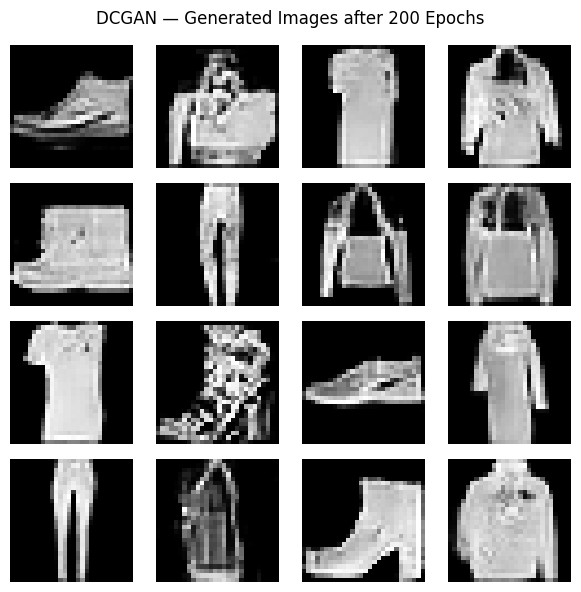

All DCGAN images saved in: /content/images/dcgan


In [ ]:
# ── Final visualisation ────────────────────────────────────────────────
G.eval()
with torch.no_grad():
    z         = torch.randn(16, latent_dim, device=device)
    fake_imgs = G(z).cpu()

fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(fake_imgs[i][0], cmap='gray')
    ax.axis('off')
plt.suptitle("DCGAN — Generated Images after 200 Epochs")
plt.tight_layout()
plt.savefig(os.path.join(image_dir, "final.png"), dpi=100, bbox_inches='tight')
plt.show()
print(f"All DCGAN images saved in: {image_dir}")

In [ ]:
import torchvision
from PIL import Image
import os

dataset = torchvision.datasets.FashionMNIST(root="./data", train=True, download=False)
test_dataset = torchvision.datasets.FashionMNIST(root="./data", train=False, download=False)

class_names = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle_boot"]

for idx, (img, label) in enumerate(dataset):
    class_dir = f"./FashionMNIST_png/train/{class_names[label]}"
    os.makedirs(class_dir, exist_ok=True)
    img.save(f"{class_dir}/{idx:05d}.png")
    if idx % 5000 == 0:
        print(f"Train: {idx}/{len(dataset)}")

for idx, (img, label) in enumerate(test_dataset):
    class_dir = f"./FashionMNIST_png/test/{class_names[label]}"
    os.makedirs(class_dir, exist_ok=True)
    img.save(f"{class_dir}/{idx:05d}.png")
    if idx % 1000 == 0:
        print(f"Test: {idx}/{len(test_dataset)}")

print("Done!")

Train: 0/60000
Train: 5000/60000
Train: 10000/60000
Train: 15000/60000
Train: 20000/60000
Train: 25000/60000
Train: 30000/60000
Train: 35000/60000
Train: 40000/60000
Train: 45000/60000
Train: 50000/60000
Train: 55000/60000
Test: 0/10000
Test: 1000/10000
Test: 2000/10000
Test: 3000/10000
Test: 4000/10000
Test: 5000/10000
Test: 6000/10000
Test: 7000/10000
Test: 8000/10000
Test: 9000/10000
Done!


In [ ]:
import shutil
shutil.make_archive("FashionMNIST_png", "zip", "./FashionMNIST_png")
print("ZIP ready — download FashionMNIST_png.zip from the Files panel on the left")

ZIP ready — download FashionMNIST_png.zip from the Files panel on the left
